## METHOD 1 ##

Adding a new regression head to the papagei model

In [35]:
import torch
import os
import re
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import h5py
from tqdm import tqdm

import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import matplotlib
matplotlib.use("Agg")

import sys
sys.path.append("/data1/yashvi_bhuva/anemia/PPG_BP/PaPaGei/papagei-foundation-model")
import pyPPG.preproc as PP
from dotmap import DotMap
from linearprobing.utils import resample_batch_signal, load_model_without_module_prefix
from models.resnet import ResNet1DMoE

In [36]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


In [37]:
RAW_DIR = "/data1/yashvi_bhuva/anemia/PPG_BP/ppg_data"             # folder of raw .txt files, e.g. "2_1.txt"
FS_ORIGINAL = 1000                 # PPG-BP native sampling rate — confirm
FS_TARGET_PAPAGEI = 125            # PaPaGei-S expected input rate
WEIGHTS_PATH = "papagei-foundation-model/weights/papagei_s.pt"
METADATA_PATH = "/data1/yashvi_bhuva/anemia/PPG_BP/PPG-BP dataset.xlsx"

In [38]:
# Loading the PaPaGei model
model_config = {
    'base_filters': 32, 'kernel_size': 3, 'stride': 2, 'groups': 1,
    'n_block': 18, 'n_classes': 512, 'n_experts': 3
}
papagei = ResNet1DMoE(in_channels=1, **model_config)
papagei = load_model_without_module_prefix(papagei, WEIGHTS_PATH)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
papagei.to(device).eval()

cuda


ResNet1DMoE(
  (first_block_conv): MyConv1dPadSame(
    (conv): Conv1d(1, 32, kernel_size=(3,), stride=(1,))
  )
  (first_block_bn): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (first_block_relu): ReLU()
  (basicblock_list): ModuleList(
    (0): BasicBlock(
      (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu1): ReLU()
      (do1): Dropout(p=0.5, inplace=False)
      (conv1): MyConv1dPadSame(
        (conv): Conv1d(32, 32, kernel_size=(3,), stride=(1,))
      )
      (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu2): ReLU()
      (do2): Dropout(p=0.5, inplace=False)
      (conv2): MyConv1dPadSame(
        (conv): Conv1d(32, 32, kernel_size=(3,), stride=(1,))
      )
      (max_pool): MyMaxPool1dPadSame(
        (max_pool): MaxPool1d(kernel_size=1, stride=1, padding=0, dilation=1, ceil_mode=False)
      )
    )
    

In [39]:
#Freezeall the layer weights
for param in papagei.parameters():
    param.requires_grad = False

sum(p.requires_grad for p in papagei.parameters())

0

In [40]:
x = torch.randn(2,1,625).to(device)

with torch.no_grad():
    y = papagei(x)

print(type(y))

if isinstance(y, tuple):
    print(len(y))
    for i,v in enumerate(y):
        print(i, v.shape)
else:
    print(y.shape)

<class 'tuple'>
4
0 torch.Size([2, 512])
1 torch.Size([2, 1])
2 torch.Size([2, 1])
3 torch.Size([2, 512])


In [41]:
class BPModel(nn.Module):

    def __init__(self, papagei):

        super().__init__()

        self.encoder = papagei

        self.regressor = nn.Sequential(

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 2)      # SBP, DBP

        )

    def forward(self, x):

        outputs = self.encoder(x)

        embedding = outputs[0]      # (batch,512)

        prediction = self.regressor(embedding)

        return prediction

In [42]:
def preprocess_one_ppg_signal(waveform, frequency, fL=0.5, fH=12, order=4,
                                smoothing_windows={"ppg": 50, "vpg": 10, "apg": 10, "jpg": 10}):
    prep = PP.Preprocess(fL=fL, fH=fH, order=order, sm_wins=smoothing_windows)
    signal = DotMap()
    signal.v = waveform
    signal.fs = frequency
    signal.filtering = True
    ppg, ppg_d1, ppg_d2, ppg_d3 = prep.get_signals(signal)
    return ppg, ppg_d1, ppg_d2, ppg_d3


def is_signal_flat_lined_simple(sig, fs, flat_threshold=0.25, change_threshold=0.01, window_ms=20):
    sig = np.asarray(sig, dtype=float)
    sig_norm = (sig - np.mean(sig)) / (np.std(sig) + 1e-8)

    step = max(1, int(fs * window_ms / 1000))  # compare samples ~20ms apart, not adjacent
    diffs = np.abs(sig_norm[step:] - sig_norm[:-step])
    flat_fraction = np.sum(diffs < change_threshold) / len(diffs)
    return 1 if flat_fraction > flat_threshold else 0

In [43]:
signals = []

sbp_labels = []
dbp_labels = []

subject_ids = []
segments = []

filenames = []

In [44]:
fname_pattern = re.compile(r"^(\d+)_(\d+)")

meta = pd.read_excel(METADATA_PATH, sheet_name="cardiovascular dataset", header=1)
meta["subject_ID"] = meta["subject_ID"].astype(int)
meta = meta.set_index("subject_ID")
for file in tqdm(os.listdir(RAW_DIR)):

    try:

        match = fname_pattern.match(file)

        if match is None:
            continue

        subject_id = int(match.group(1))
        segment = int(match.group(2))

        if subject_id not in meta.index:
            continue

        ##################################################
        # Load raw signal
        ##################################################

        raw_ppg = np.loadtxt(
            os.path.join(RAW_DIR, file)
        )

        ##################################################
        # Filter
        ##################################################

        ppg_filt, _, _, _ = preprocess_one_ppg_signal(
            waveform=raw_ppg,
            frequency=FS_ORIGINAL
        )

        ##################################################
        # Quality check
        ##################################################

        if is_signal_flat_lined_simple(
            ppg_filt,
            fs=FS_ORIGINAL
        ):
            continue

        ##################################################
        # Resample
        ##################################################

        resampled = resample_batch_signal(
            ppg_filt[np.newaxis, :],
            fs_original=FS_ORIGINAL,
            fs_target=FS_TARGET_PAPAGEI,
            axis=-1
        ).squeeze()

        ##################################################
        # Labels
        ##################################################

        row = meta.loc[subject_id]

        signals.append(resampled.astype(np.float32))

        sbp_labels.append(
            row["Systolic Blood Pressure(mmHg)"]
        )

        dbp_labels.append(
            row["Diastolic Blood Pressure(mmHg)"]
        )

        subject_ids.append(subject_id)

        segments.append(segment)

        filenames.append(file)

    except Exception as e:

        print(file, e)

100%|██████████| 657/657 [00:01<00:00, 372.32it/s]


In [45]:
MAX_LEN = 525

signals_padded = []

for sig in signals:
    if len(sig) < MAX_LEN:
        pad = MAX_LEN - len(sig)
        sig = np.pad(sig, (0, pad), mode="edge") # Edge padding to avoid introducing new values and it produces a more natural continuation of the signal
    signals_padded.append(sig.astype(np.float32))

signals = np.stack(signals_padded)

In [46]:
signals = np.stack(signals)

sbp_labels = np.array(sbp_labels)

dbp_labels = np.array(dbp_labels)

subject_ids = np.array(subject_ids)

segments = np.array(segments)

filenames = np.array(filenames, dtype="S")

In [47]:
data = pd.DataFrame({
    "signal_idx": np.arange(len(signals)),
    "SBP": sbp_labels,
    "DBP": dbp_labels,
    "subject_id": subject_ids,
    "segment": segments,
    "file": filenames
})

print(data.head())
print(data.shape)

   signal_idx  SBP  DBP  subject_id  segment          file
0           0  130   66         105        1  b'105_1.txt'
1           1  141   67         139        2  b'139_2.txt'
2           2  150   96          38        2   b'38_2.txt'
3           3  149   71         138        2  b'138_2.txt'
4           4  102   55         405        1  b'405_1.txt'
(657, 6)


In [48]:
#Subject-wise split of data into train and test sets to avoid data leakage
from sklearn.model_selection import GroupShuffleSplit


# First split: train + temp(test+val)
splitter1 = GroupShuffleSplit(
    test_size=0.3,
    random_state=42
)


train_idx, temp_idx = next(
    splitter1.split(
        data,
        groups=data["subject_id"]
    )
)


train_df = data.iloc[train_idx].reset_index(drop=True)
temp_df = data.iloc[temp_idx].reset_index(drop=True)



# Second split: validation + test
splitter2 = GroupShuffleSplit(
    test_size=0.5,
    random_state=42
)


val_idx, test_idx = next(
    splitter2.split(
        temp_df,
        groups=temp_df["subject_id"]
    )
)


val_df = temp_df.iloc[val_idx].reset_index(drop=True)

test_df = temp_df.iloc[test_idx].reset_index(drop=True)



print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))


print("\nSubjects:")
print("Train:", train_df.subject_id.nunique())
print("Val:", val_df.subject_id.nunique())
print("Test:", test_df.subject_id.nunique())

Train: 459
Validation: 99
Test: 99

Subjects:
Train: 153
Val: 33
Test: 33


In [49]:
class PPGDataset(Dataset):

    def __init__(self, dataframe, signals):

        self.df = dataframe.reset_index(drop=True)
        self.signals = signals


    def __len__(self):

        return len(self.df)


    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        signal_idx = row.signal_idx


        # Already filtered, resampled, padded
        signal = self.signals[signal_idx]


        # Papagei expects channel dimension
        signal = torch.tensor(
            signal,
            dtype=torch.float32
        ).unsqueeze(0)


        target = torch.tensor(
            [
                row.SBP,
                row.DBP
            ],
            dtype=torch.float32
        )


        return signal, target

In [50]:
train_dataset = PPGDataset(
    train_df,
    signals
)

val_dataset = PPGDataset(
    val_df,
    signals
)
test_dataset = PPGDataset(
    test_df,
    signals
)


train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)


val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [51]:
#To verify that there is no data leakage between train, validation and test sets, we can check the number of common subjects between them. If the number is zero, it means there is no data leakage.
print(
    len(
        set(train_df.subject_id)
        &
        set(test_df.subject_id)
    )
)

print(
    len(
        set(train_df.subject_id)
        &
        set(val_df.subject_id)
    )
)

0
0


In [52]:
x, y = next(iter(train_loader))

print("Input shape:", x.shape)
print("Target shape:", y.shape)

print("Signal range:", x.min(), x.max())
print("Labels:", y[:5])

Input shape: torch.Size([32, 1, 525])
Target shape: torch.Size([32, 2])
Signal range: tensor(-1073.4005) tensor(1212.7225)
Labels: tensor([[160.,  93.],
        [131.,  74.],
        [149.,  70.],
        [108.,  66.],
        [128.,  79.]])


In [53]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# move one batch to device
x = x.to(device)

# load only the encoder part
papagei = papagei.to(device)
papagei.eval()

with torch.no_grad():

    outputs = papagei(x)


print("Output type:", type(outputs))


if isinstance(outputs, tuple):
    print("Number of outputs:", len(outputs))
    print("First output shape:", outputs[0].shape)

else:
    print("Output shape:", outputs.shape)

Output type: <class 'tuple'>
Number of outputs: 4
First output shape: torch.Size([32, 512])


In [54]:
model = BPModel(papagei)

model = model.to(device)

print(model)

BPModel(
  (encoder): ResNet1DMoE(
    (first_block_conv): MyConv1dPadSame(
      (conv): Conv1d(1, 32, kernel_size=(3,), stride=(1,))
    )
    (first_block_bn): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (first_block_relu): ReLU()
    (basicblock_list): ModuleList(
      (0): BasicBlock(
        (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu1): ReLU()
        (do1): Dropout(p=0.5, inplace=False)
        (conv1): MyConv1dPadSame(
          (conv): Conv1d(32, 32, kernel_size=(3,), stride=(1,))
        )
        (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu2): ReLU()
        (do2): Dropout(p=0.5, inplace=False)
        (conv2): MyConv1dPadSame(
          (conv): Conv1d(32, 32, kernel_size=(3,), stride=(1,))
        )
        (max_pool): MyMaxPool1dPadSame(
          (max_pool): MaxPool1d(kernel_size=1, stri

In [55]:
for name, param in model.named_parameters():

    if param.requires_grad:
        print(name)

regressor.0.weight
regressor.0.bias
regressor.3.weight
regressor.3.bias
regressor.6.weight
regressor.6.bias


In [56]:
total = 0
trainable = 0

for p in model.parameters():

    total += p.numel()

    if p.requires_grad:
        trainable += p.numel()

print("Total parameters :", total)
print("Trainable parameters :", trainable)

Total parameters : 5950094
Trainable parameters : 164482


In [57]:
with torch.no_grad():

    pred = model(x)


print("Prediction shape:", pred.shape)

Prediction shape: torch.Size([32, 2])


In [58]:
import torch.optim as optim

criterion = nn.SmoothL1Loss()


optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-5,
    weight_decay=1e-4
)

In [59]:
import matplotlib.pyplot as plt

epochs = 100

best_val_loss = float("inf")

train_losses = []
val_losses = []


for epoch in range(epochs):

    # -----------------
    # Training
    # -----------------
    model.train()

    train_loss = 0.0


    for signals, targets in train_loader:

        signals = signals.to(device)
        targets = targets.to(device)


        optimizer.zero_grad()


        predictions = model(signals)


        loss = criterion(
            predictions,
            targets
        )


        loss.backward()

        optimizer.step()


        train_loss += loss.item()



    train_loss /= len(train_loader)

    train_losses.append(train_loss)



    # -----------------
    # Validation
    # -----------------
    model.eval()

    val_loss = 0.0


    with torch.no_grad():

        for signals, targets in val_loader:

            signals = signals.to(device)
            targets = targets.to(device)


            predictions = model(signals)


            loss = criterion(
                predictions,
                targets
            )


            val_loss += loss.item()



    val_loss /= len(val_loader)

    val_losses.append(val_loss)



    # Save best model
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            "best_papagei_bp_model.pth"
        )


    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f}"
    )



Epoch [1/100] Train Loss: 99.7356 Val Loss: 98.0196
Epoch [2/100] Train Loss: 99.0875 Val Loss: 98.0112
Epoch [3/100] Train Loss: 99.5127 Val Loss: 98.0008
Epoch [4/100] Train Loss: 99.1919 Val Loss: 97.9924
Epoch [5/100] Train Loss: 99.9341 Val Loss: 97.9830
Epoch [6/100] Train Loss: 99.2292 Val Loss: 97.9772
Epoch [7/100] Train Loss: 99.0165 Val Loss: 97.9621
Epoch [8/100] Train Loss: 99.3545 Val Loss: 97.9486
Epoch [9/100] Train Loss: 99.3406 Val Loss: 97.9396
Epoch [10/100] Train Loss: 99.4122 Val Loss: 97.9323
Epoch [11/100] Train Loss: 99.5626 Val Loss: 97.9170
Epoch [12/100] Train Loss: 99.0823 Val Loss: 97.9047
Epoch [13/100] Train Loss: 99.4395 Val Loss: 97.8908
Epoch [14/100] Train Loss: 99.0713 Val Loss: 97.8617
Epoch [15/100] Train Loss: 99.2718 Val Loss: 97.8424
Epoch [16/100] Train Loss: 99.1214 Val Loss: 97.8136
Epoch [17/100] Train Loss: 99.0945 Val Loss: 97.8030
Epoch [18/100] Train Loss: 99.2178 Val Loss: 97.7734
Epoch [19/100] Train Loss: 98.9625 Val Loss: 97.7479
Ep

In [60]:
test_losses = []
model.eval()

test_loss = 0.0

all_preds = []
all_targets = []


with torch.no_grad():

    for signals, targets in test_loader:

        signals = signals.to(device)
        targets = targets.to(device)


        predictions = model(signals)


        loss = criterion(
            predictions,
            targets
        )


        test_loss += loss.item()


        # store predictions and labels
        all_preds.append(
            predictions.cpu()
        )

        all_targets.append(
            targets.cpu()
        )


test_loss /= len(test_loader)


all_preds = torch.cat(all_preds).numpy()
all_targets = torch.cat(all_targets).numpy()


print("Test Loss:", test_loss)


Test Loss: 85.83807563781738


In [62]:
if val_loss < best_val_loss:
    best_val_loss = val_loss
    torch.save(
        model.state_dict(),
        "best_papagei_bp_model.pth"
    )

print("Saved best model")

Saved best model


In [63]:
model.load_state_dict(
    torch.load("best_papagei_bp_model.pth")
)

model.eval()

BPModel(
  (encoder): ResNet1DMoE(
    (first_block_conv): MyConv1dPadSame(
      (conv): Conv1d(1, 32, kernel_size=(3,), stride=(1,))
    )
    (first_block_bn): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (first_block_relu): ReLU()
    (basicblock_list): ModuleList(
      (0): BasicBlock(
        (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu1): ReLU()
        (do1): Dropout(p=0.5, inplace=False)
        (conv1): MyConv1dPadSame(
          (conv): Conv1d(32, 32, kernel_size=(3,), stride=(1,))
        )
        (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu2): ReLU()
        (do2): Dropout(p=0.5, inplace=False)
        (conv2): MyConv1dPadSame(
          (conv): Conv1d(32, 32, kernel_size=(3,), stride=(1,))
        )
        (max_pool): MyMaxPool1dPadSame(
          (max_pool): MaxPool1d(kernel_size=1, stri

In [64]:
all_preds = []
all_targets = []


with torch.no_grad():

    for signals, targets in val_loader:

        signals = signals.to(device)

        preds = model(signals)


        all_preds.append(
            preds.cpu()
        )

        all_targets.append(
            targets
        )


all_preds = torch.cat(all_preds).numpy()
all_targets = torch.cat(all_targets).numpy()

In [65]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


pred_sbp = all_preds[:,0]
pred_dbp = all_preds[:,1]


true_sbp = all_targets[:,0]
true_dbp = all_targets[:,1]



sbp_mae = mean_absolute_error(
    true_sbp,
    pred_sbp
)

dbp_mae = mean_absolute_error(
    true_dbp,
    pred_dbp
)



sbp_rmse = np.sqrt(
    mean_squared_error(
        true_sbp,
        pred_sbp
    )
)

dbp_rmse = np.sqrt(
    mean_squared_error(
        true_dbp,
        pred_dbp
    )
)



print("SBP MAE:", sbp_mae)
print("DBP MAE:", dbp_mae)

print("SBP RMSE:", sbp_rmse)
print("DBP RMSE:", dbp_rmse)

SBP MAE: 113.462814
DBP MAE: 56.97057
SBP RMSE: 115.7254
DBP RMSE: 59.4951


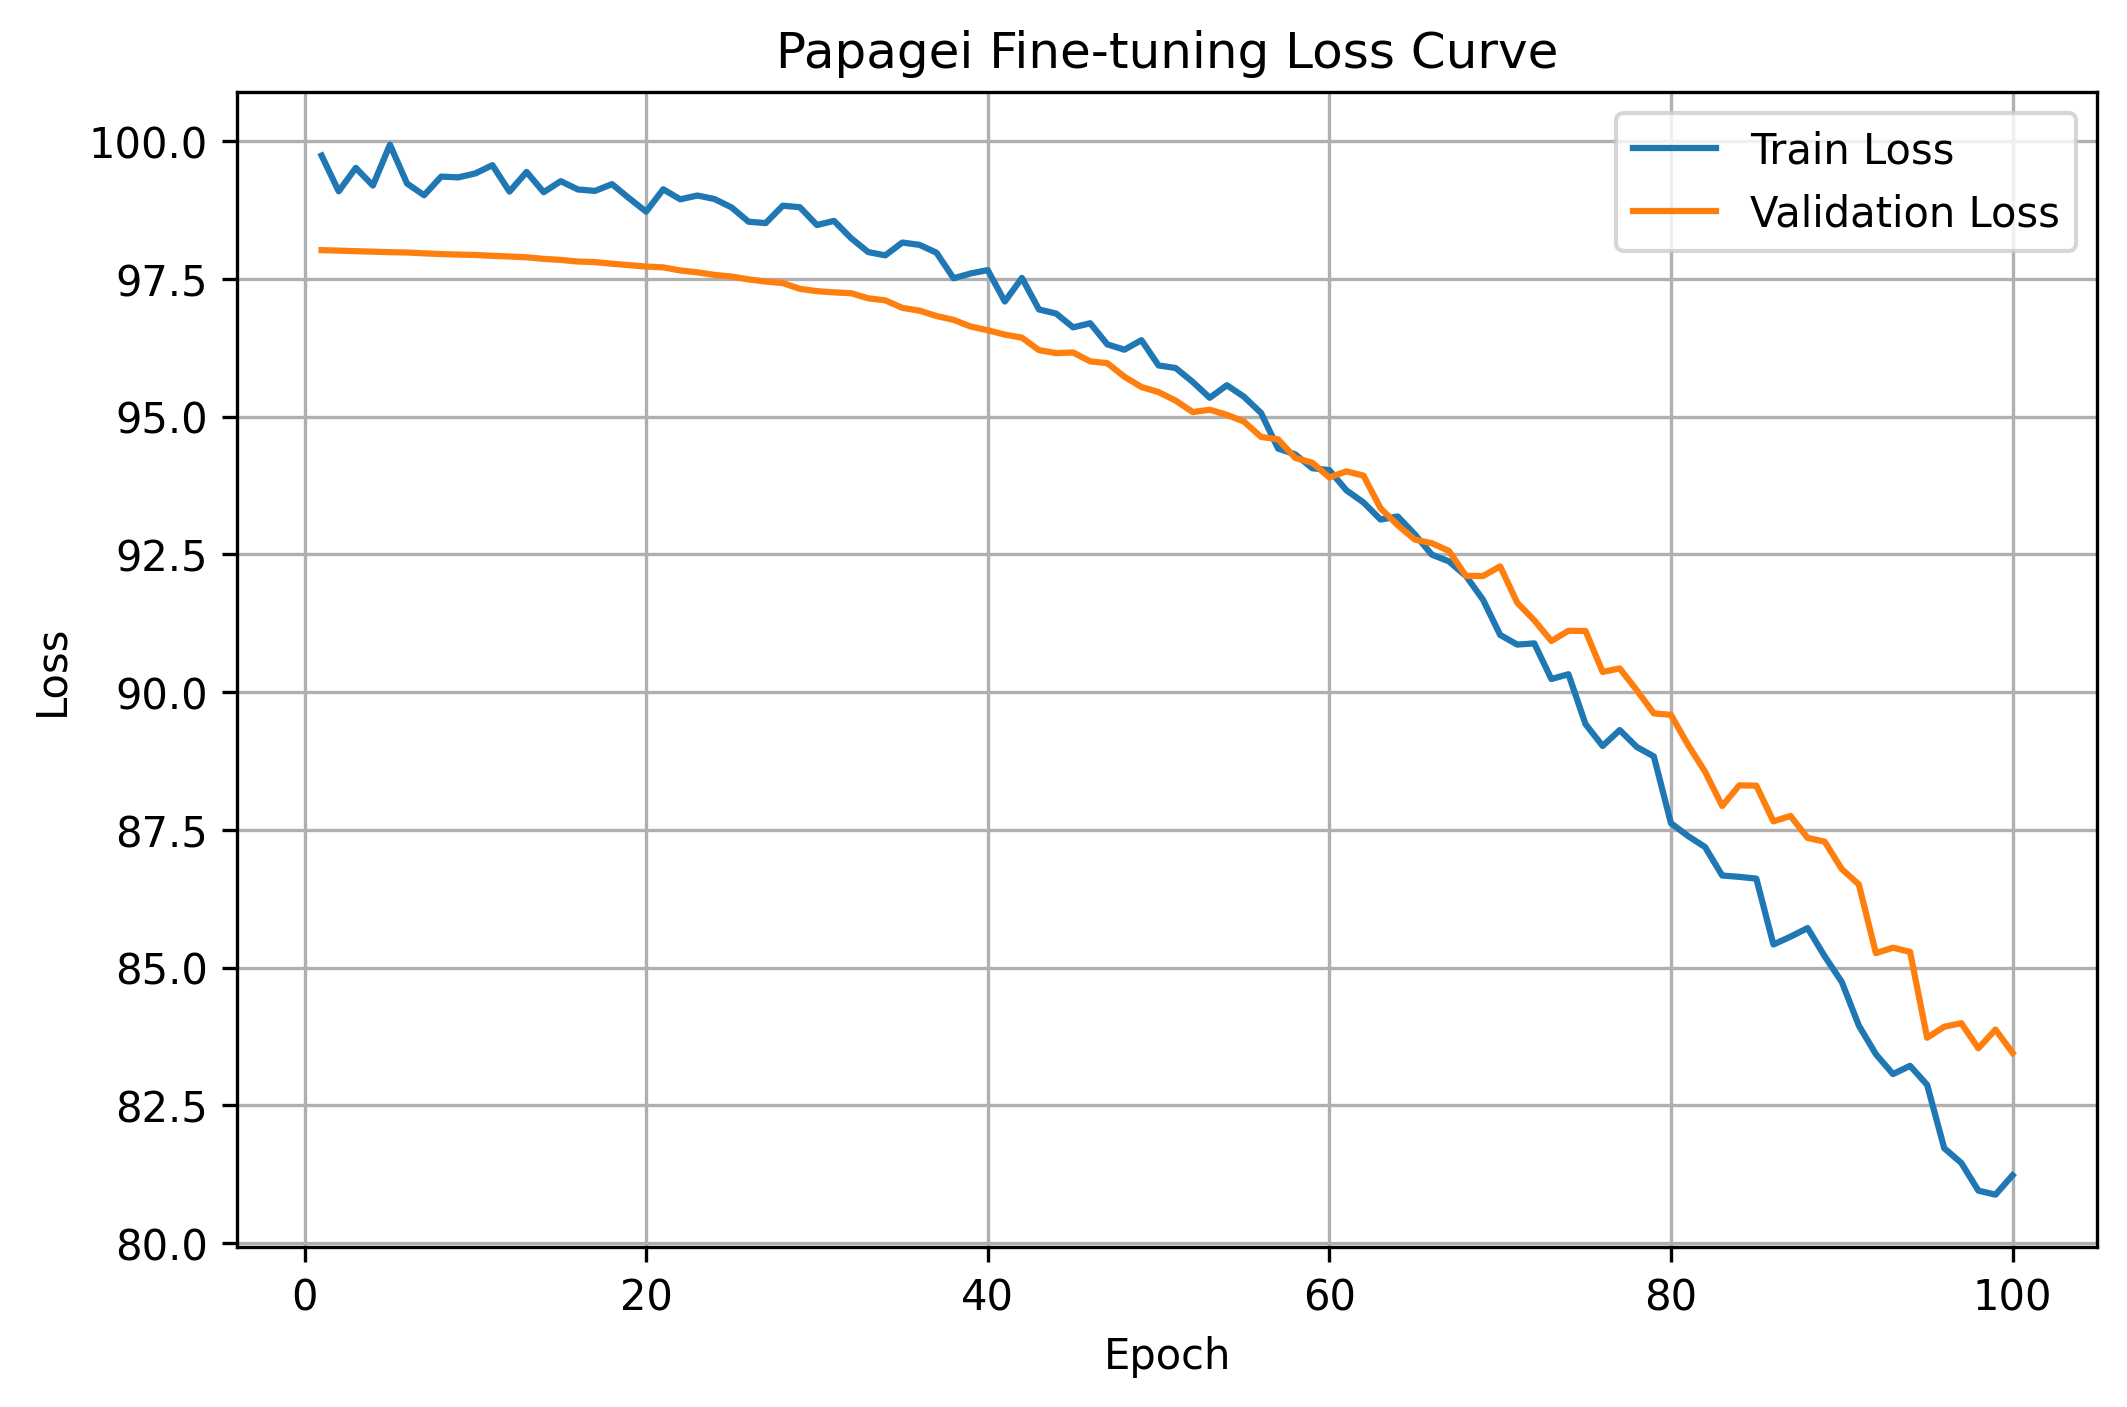

In [66]:
from IPython.display import Image, display


plt.figure(figsize=(8,5))

plt.plot(
    range(1, epochs+1),
    train_losses,
    label="Train Loss"
)

plt.plot(
    range(1, epochs+1),
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Papagei Fine-tuning Loss Curve")

plt.legend()
plt.grid(True)

plt.savefig(
    "loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()


display(Image("loss_curve.png"))